In [ ]:
import pandas as pd
import squarify
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/metadata/trials_summary.csv')
df['Legal_Proceeding'] = (
    df['Legal_Proceeding']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r's$', '', regex=True)
)
proceeding_counts = df['Legal_Proceeding'].dropna().value_counts()
print(len(proceeding_counts))
print("Normalized Legal Proceeding types and their counts:\n")
for proceeding, count in proceeding_counts.items():
    print(f"{proceeding.capitalize()}: {count}")

66
Normalized Legal Proceeding types and their counts:

Deposition: 227
Indictment: 118
Testimony: 105
Examination: 102
Petition: 88
Warrant: 71
Statement: 32
Recognizance: 23
Order for payment: 22
Complaint: 21
Record: 19
Summon: 19
Case: 14
Return: 13
Letter: 10
Account for payment: 10
Account submitted for payment: 8
Mittimu: 8
Summary: 4
Act to reverse: 4
Fragment: 3
Witnesse: 3
Report: 3
Declaration: 3
Physical examination: 3
Account for restitution: 2
Court record: 2
Order of the superior: 2
Continuation: 2
Increase: 2
Response of general: 2
Nan: 2
Testimonie: 2
Fragment of examination: 2
Council record: 1
Jail account: 1
Second: 1
Resolve: 1
Account: 1
Petitiion: 1
Expense: 1
Memorandum: 1
Request: 1
Division of money: 1
Order for restitution: 1
Receipt: 1
Order for petition: 1
Plea: 1
Final action: 1
Excuse: 1
Report of payment: 1
Recantation: 1
Statementof: 1
Judgment: 1
Release: 1
List of witnesse: 1
Statemen: 1
Bill: 1
Censu: 1
List: 1
Oath: 1
Appeal: 1
Placement: 1
Desposit

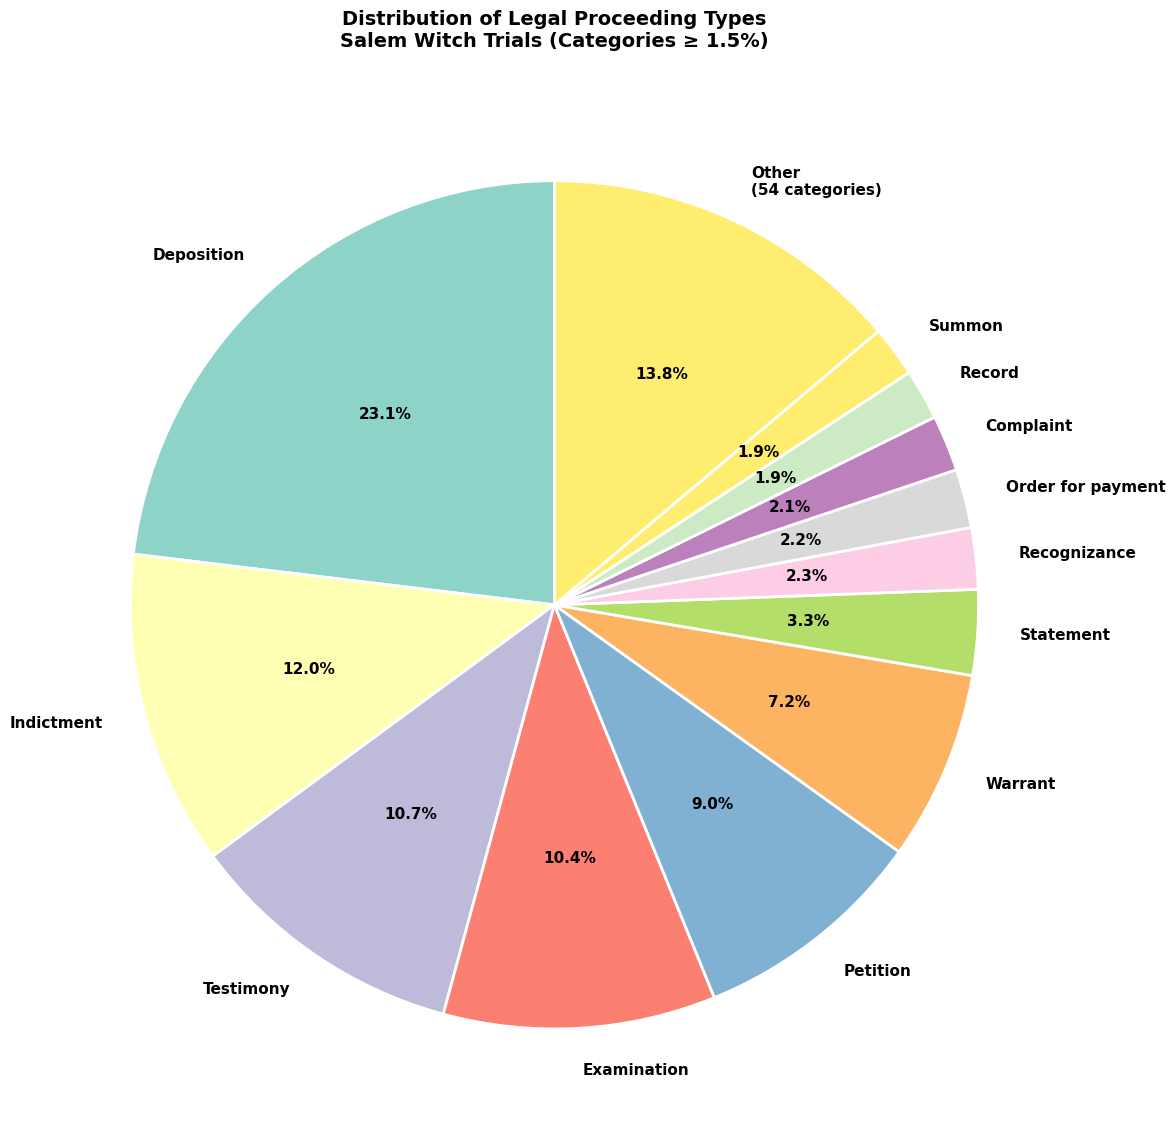

In [8]:
plt.figure(figsize=(12, 12))

# Group categories with < 1.5% into "Other"
threshold = 0.015
total = proceeding_counts.sum()

major_categories = proceeding_counts[proceeding_counts / total >= threshold]
minor_sum = proceeding_counts[proceeding_counts / total < threshold].sum()

plot_data = pd.concat([major_categories, pd.Series({'Other\n(54 categories)': minor_sum})])

# Create pie chart with better colors
colors = plt.cm.Set3(range(len(plot_data)))

plt.pie(plot_data, labels=[f"{k.capitalize()}" for k in plot_data.index], 
        autopct='%1.1f%%',
        startangle=90, 
        colors=colors,
        textprops={'fontsize': 11, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.title('Distribution of Legal Proceeding Types\nSalem Witch Trials (Categories ≥ 1.5%)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('legal_proceedings_pie.png', dpi=300, bbox_inches='tight')
plt.show()